In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity

In [2]:
df = pd.read_csv("Testing_imputation.csv")

df = df.interpolate(method='linear', limit_direction='forward', axis=0)

df_numeric = df.drop(columns=['Country', 'Year'])

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

/var/folders/8j/s4crl2511pdg9vg6q8sk1qzw0000gn/T/ipykernel_2906/909666298.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear', limit_direction='forward', axis=0)


In [3]:
kmo_all, kmo_model = calculate_kmo(df_scaled)
print("KMO Test:", kmo_model)  # Should be >0.6 ideally

chi_square_value, p_value = calculate_bartlett_sphericity(df_scaled)
print("Bartlett’s Test Chi-square:", chi_square_value, "p-value:", p_value)

KMO Test: 0.7009596361132987
Bartlett’s Test Chi-square: 170586.01412544984 p-value: 0.0


Eigenvalues: [4.44553969 1.9095495  1.17082066 1.14308361 0.74301449 0.37083871
 0.15338397 0.03580625 0.01998265 0.00798046]


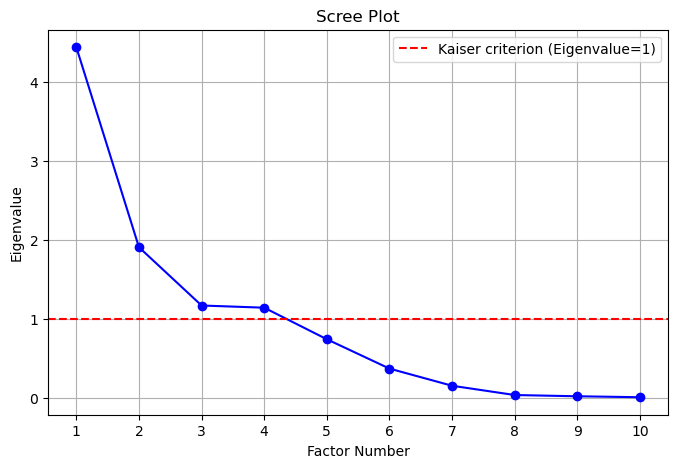

In [6]:
corr_matrix = np.corrcoef(df_scaled.T)
eigenvalues, _ = np.linalg.eig(corr_matrix)
print("Eigenvalues:", eigenvalues)

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='blue')
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser criterion (Eigenvalue=1)')
plt.title('Scree Plot')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.xticks(range(1, len(eigenvalues)+1))
plt.legend()
plt.grid(True)
plt.show()

In [7]:
n_factors = np.sum(eigenvalues > 1)  # Kaiser criterion

In [8]:
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(df_scaled)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,n_factors,np.int64(4)
,rotation,'varimax'
,method,'minres'
,use_smc,True
,is_corr_matrix,False
,bounds,"(0.005, ...)"
,impute,'median'
,svd_method,'randomized'
,rotation_kwargs,{}


In [9]:
loadings = pd.DataFrame(fa.loadings_, index=df_numeric.columns, columns=[f'Factor{i+1}' for i in range(n_factors)])
print("\nFactor Loadings:\n", loadings)

# Variance explained
variance = pd.DataFrame(fa.get_factor_variance(), 
                        index=['Variance', 'Proportional Variance', 'Cumulative Variance'], 
                        columns=[f'Factor{i+1}' for i in range(n_factors)])
print("\nVariance Explained:\n", variance)


Factor Loadings:
                                  Factor1   Factor2   Factor3   Factor4
GDP_Growth_Rate                -0.007145 -0.064591  0.980392 -0.172948
Inflation_Rate                  0.002260 -0.021144 -0.074715  0.340256
GDP_Per_Capita                  0.043858  0.855385  0.038520  0.233114
Unemployment_Rate              -0.025355 -0.055651 -0.188455 -0.200538
Cost of Living Index           -0.935298  0.118242  0.039105  0.183663
Rent Index                     -0.891543  0.206018  0.065403  0.374233
Cost of Living Plus Rent Index  0.974576  0.052806  0.055386  0.208676
Groceries Index                 0.966713 -0.000192  0.097569  0.168034
Restaurant Price Index          0.918941  0.242974 -0.008435  0.125037
Local Purchasing Power Index   -0.047640  0.953120 -0.043216 -0.218637

Variance Explained:
                         Factor1   Factor2   Factor3   Factor4
Variance               4.403307  1.766087  1.024083  0.549243
Proportional Variance  0.440331  0.176609  0.102408  0